In [10]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, precision_recall_curve, auc
)
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras import models, layers
from tensorflow.keras.utils import to_categorical

In [11]:
# Load data
train_standard_df = pd.read_csv('./train_standard_methylation.csv')
test_standard_df = pd.read_csv('./test_standard_methylation.csv')
train_minmax_df = pd.read_csv('./train_minmax_methylation.csv')
test_minmax_df = pd.read_csv('./test_minmax_methylation.csv')


In [12]:
# Separate features and target for both standard and minmax datasets
X_train_standard = train_standard_df.drop(columns=['target'])
y_train_standard = train_standard_df['target']
X_test_standard = test_standard_df.drop(columns=['target'])
y_test_standard = test_standard_df['target']

X_train_minmax = train_minmax_df.drop(columns=['target'])
y_train_minmax = train_minmax_df['target']
X_test_minmax = test_minmax_df.drop(columns=['target'])
y_test_minmax = test_minmax_df['target']


In [13]:
# Updated evaluate_model function to return metrics
def evaluate_model(y_true, y_pred, y_proba=None):
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=1),
        "recall": recall_score(y_true, y_pred, zero_division=1),
        "f1_score": f1_score(y_true, y_pred, zero_division=1)
    }
    if y_proba is not None:
        metrics["roc_auc"] = roc_auc_score(y_true, y_proba)
        precision, recall, _ = precision_recall_curve(y_true, y_proba)
        metrics["auprc"] = auc(recall, precision)
    
    # Print individual metrics for the fold
    for key, value in metrics.items():
        print(f"{key.capitalize()}: {value:.4f}")
    
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Confusion Matrix')
    plt.show()
    
    return metrics

In [14]:
# Logistic Regression Model with Cross-Validation (Full Metrics for Each Fold)
def logistic_regression_cv(X, y):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    fold = 1
    all_metrics = []

    for train_index, val_index in cv.split(X, y):
        print(f"\nTraining on Fold {fold}")
        X_train_cv, X_val_cv = X.iloc[train_index], X.iloc[val_index]
        y_train_cv, y_val_cv = y.iloc[train_index], y.iloc[val_index]

        model = LogisticRegression(class_weight='balanced')
        model.fit(X_train_cv, y_train_cv)

        # Predictions and Evaluation for the current fold
        y_pred = model.predict(X_val_cv)
        y_proba = model.predict_proba(X_val_cv)[:, 1]  # Probability of positive class
        print(f"Fold {fold} Metrics:")
        fold_metrics = evaluate_model(y_val_cv, y_pred, y_proba)
        all_metrics.append(fold_metrics)

        fold += 1

    # Calculate and print average metrics across all folds
    avg_metrics = {metric: np.mean([fold_metrics[metric] for fold_metrics in all_metrics]) for metric in all_metrics[0]}
    print("\nAverage Metrics Across All Folds for Logistic Regression:")
    for key, value in avg_metrics.items():
        print(f"{key.capitalize()}: {value:.4f}")


In [15]:
# Feedforward Neural Network Model with Cross-Validation (Full Metrics for Each Fold)
def fnn_cv(X, y, input_dim):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    fold = 1
    all_metrics = []

    for train_index, val_index in cv.split(X, y):
        print(f"\nTraining on Fold {fold}")
        X_train_cv, X_val_cv = X[train_index], X[val_index]
        y_train_cv, y_val_cv = y[train_index], y[val_index]

        # One-hot encoding for binary classification (if target is binary 0/1)
        y_train_cat = to_categorical(y_train_cv, num_classes=2)
        y_val_cat = to_categorical(y_val_cv, num_classes=2)

        # Define the model
        model = models.Sequential([
            layers.Input(shape=(input_dim,)),
            layers.Dense(64, activation='relu'),
            layers.Dense(32, activation='relu'),
            layers.Dense(2, activation='softmax')  # Output layer for binary classification
        ])

        model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

        # Train the model
        model.fit(X_train_cv, y_train_cat, epochs=10, batch_size=32, verbose=0)

        # Predictions and Evaluation for the current fold
        y_pred = np.argmax(model.predict(X_val_cv), axis=1)
        y_proba = model.predict(X_val_cv)[:, 1]  # Probability of positive class
        print(f"Fold {fold} Metrics:")
        fold_metrics = evaluate_model(y_val_cv, y_pred, y_proba)
        all_metrics.append(fold_metrics)
        
        # Analyze prediction distribution
        unique, counts = np.unique(y_pred, return_counts=True)
        print("Prediction distribution:", dict(zip(unique, counts)))

        fold += 1

    # Calculate and print average metrics across all folds
    avg_metrics = {metric: np.mean([fold_metrics[metric] for fold_metrics in all_metrics]) for metric in all_metrics[0]}
    print("\nAverage Metrics Across All Folds for FNN:")
    for key, value in avg_metrics.items():
        print(f"{key.capitalize()}: {value:.4f}")


Standard Scaled Data - Logistic Regression Cross-Validation:

Training on Fold 1
Fold 1 Metrics:
Accuracy: 0.7772
Precision: 0.2255
Recall: 0.7188
F1_score: 0.3433
Roc_auc: 0.8330
Auprc: 0.3882


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


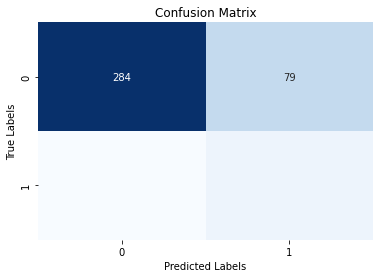


Training on Fold 2
Fold 2 Metrics:
Accuracy: 0.7671
Precision: 0.2273
Recall: 0.7812
F1_score: 0.3521
Roc_auc: 0.8733
Auprc: 0.5449


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


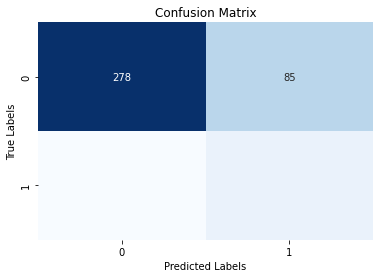


Training on Fold 3
Fold 3 Metrics:
Accuracy: 0.7392
Precision: 0.2066
Recall: 0.7812
F1_score: 0.3268
Roc_auc: 0.8377
Auprc: 0.3037


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


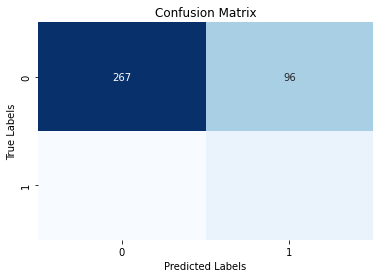


Training on Fold 4
Fold 4 Metrics:
Accuracy: 0.7418
Precision: 0.1983
Recall: 0.7188
F1_score: 0.3108
Roc_auc: 0.7821
Auprc: 0.2274


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


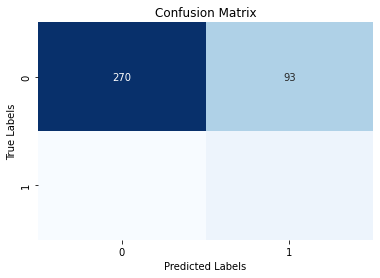


Training on Fold 5


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fold 5 Metrics:
Accuracy: 0.7392
Precision: 0.2017
Recall: 0.7500
F1_score: 0.3179
Roc_auc: 0.7902
Auprc: 0.2479


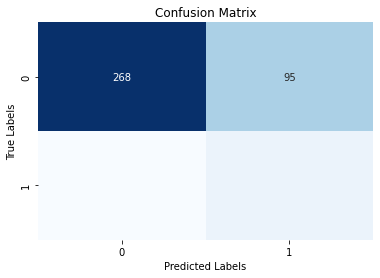


Average Metrics Across All Folds for Logistic Regression:
Accuracy: 0.7529
Precision: 0.2119
Recall: 0.7500
F1_score: 0.3302
Roc_auc: 0.8233
Auprc: 0.3424

Standard Scaled Data - FNN Cross-Validation:

Training on Fold 1
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Fold 1 Metrics:
Accuracy: 0.9139
Precision: 0.0000
Recall: 0.0000
F1_score: 0.0000
Roc_auc: 0.6580
Auprc: 0.1562


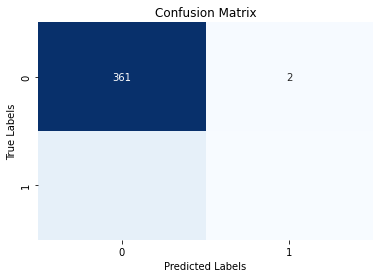

Prediction distribution: {0: 393, 1: 2}

Training on Fold 2
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Fold 2 Metrics:
Accuracy: 0.9165
Precision: 0.4286
Recall: 0.0938
F1_score: 0.1538
Roc_auc: 0.7778
Auprc: 0.2227


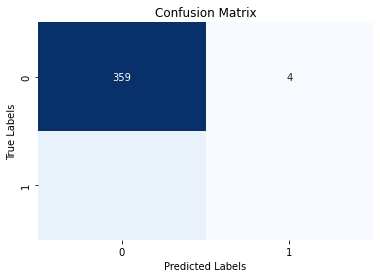

Prediction distribution: {0: 388, 1: 7}

Training on Fold 3
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Fold 3 Metrics:
Accuracy: 0.9190
Precision: 0.5000
Recall: 0.0312
F1_score: 0.0588
Roc_auc: 0.6517
Auprc: 0.1985


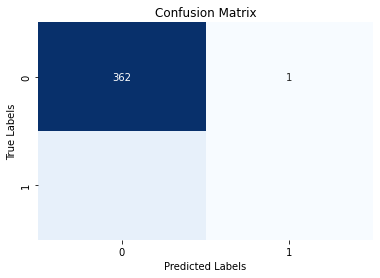

Prediction distribution: {0: 393, 1: 2}

Training on Fold 4
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Fold 4 Metrics:
Accuracy: 0.9139
Precision: 0.0000
Recall: 0.0000
F1_score: 0.0000
Roc_auc: 0.5376
Auprc: 0.0930


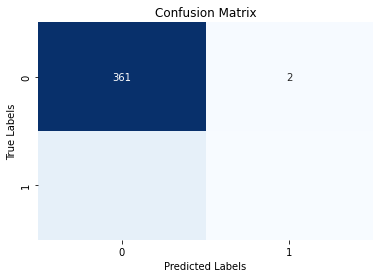

Prediction distribution: {0: 393, 1: 2}

Training on Fold 5
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Fold 5 Metrics:
Accuracy: 0.9190
Precision: 1.0000
Recall: 0.0000
F1_score: 0.0000
Roc_auc: 0.5614
Auprc: 0.1213


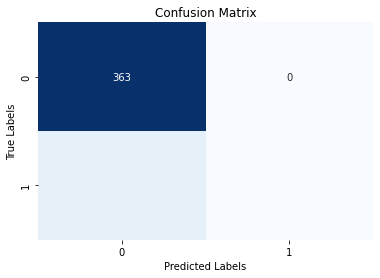

Prediction distribution: {0: 395}

Average Metrics Across All Folds for FNN:
Accuracy: 0.9165
Precision: 0.3857
Recall: 0.0250
F1_score: 0.0425
Roc_auc: 0.6373
Auprc: 0.1583


In [16]:
# Running cross-validation on Standard Scaled data
print("Standard Scaled Data - Logistic Regression Cross-Validation:")
logistic_regression_cv(X_train_standard, y_train_standard)
print("\nStandard Scaled Data - FNN Cross-Validation:")
fnn_cv(X_train_standard.values, y_train_standard.values, input_dim=X_train_standard.shape[1])



MinMax Scaled Data - Logistic Regression Cross-Validation:

Training on Fold 1
Fold 1 Metrics:
Accuracy: 0.7646
Precision: 0.2202
Recall: 0.7500
F1_score: 0.3404
Roc_auc: 0.8311
Auprc: 0.3173


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


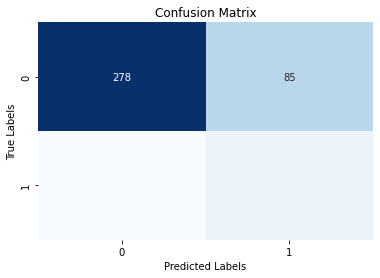


Training on Fold 2


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fold 2 Metrics:
Accuracy: 0.7367
Precision: 0.2097
Recall: 0.8125
F1_score: 0.3333
Roc_auc: 0.8642
Auprc: 0.3691


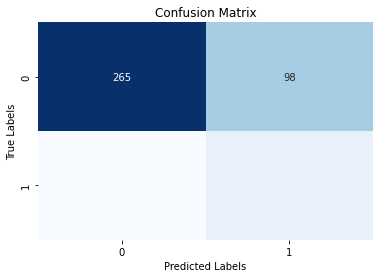


Training on Fold 3
Fold 3 Metrics:
Accuracy: 0.7595
Precision: 0.2261
Recall: 0.8125
F1_score: 0.3537
Roc_auc: 0.8614
Auprc: 0.3922


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


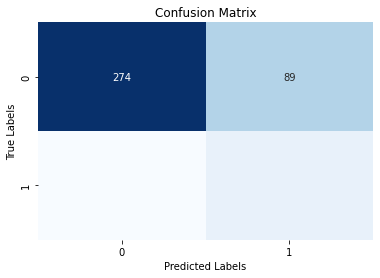


Training on Fold 4
Fold 4 Metrics:
Accuracy: 0.7443
Precision: 0.2051
Recall: 0.7500
F1_score: 0.3221
Roc_auc: 0.8178
Auprc: 0.2556


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


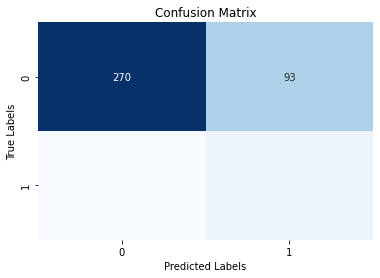


Training on Fold 5
Fold 5 Metrics:
Accuracy: 0.7367
Precision: 0.1897
Recall: 0.6875
F1_score: 0.2973
Roc_auc: 0.7966
Auprc: 0.2311


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


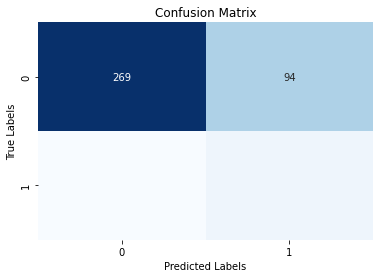


Average Metrics Across All Folds for Logistic Regression:
Accuracy: 0.7484
Precision: 0.2101
Recall: 0.7625
F1_score: 0.3294
Roc_auc: 0.8342
Auprc: 0.3131

MinMax Scaled Data - FNN Cross-Validation:

Training on Fold 1
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Fold 1 Metrics:
Accuracy: 0.9190
Precision: 1.0000
Recall: 0.0000
F1_score: 0.0000
Roc_auc: 0.5927
Auprc: 0.1340


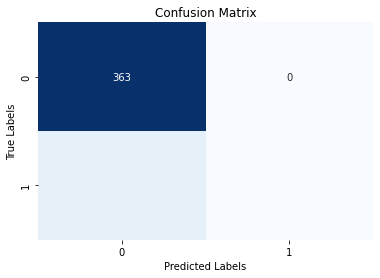

Prediction distribution: {0: 395}

Training on Fold 2
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Fold 2 Metrics:
Accuracy: 0.9190
Precision: 1.0000
Recall: 0.0000
F1_score: 0.0000
Roc_auc: 0.6849
Auprc: 0.1392


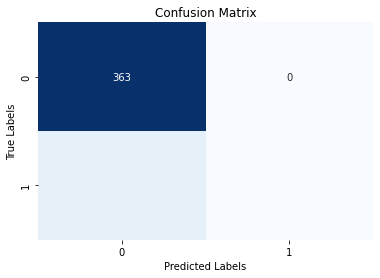

Prediction distribution: {0: 395}

Training on Fold 3
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Fold 3 Metrics:
Accuracy: 0.9190
Precision: 1.0000
Recall: 0.0000
F1_score: 0.0000
Roc_auc: 0.6235
Auprc: 0.1772


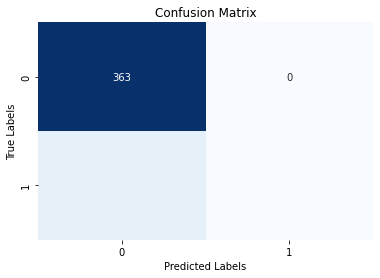

Prediction distribution: {0: 395}

Training on Fold 4
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Fold 4 Metrics:
Accuracy: 0.9190
Precision: 1.0000
Recall: 0.0000
F1_score: 0.0000
Roc_auc: 0.6580
Auprc: 0.2024


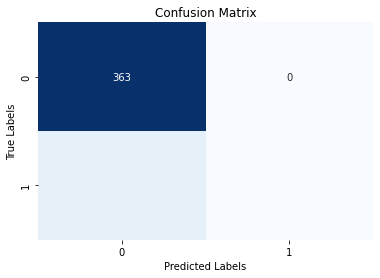

Prediction distribution: {0: 395}

Training on Fold 5
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Fold 5 Metrics:
Accuracy: 0.9190
Precision: 1.0000
Recall: 0.0000
F1_score: 0.0000
Roc_auc: 0.5170
Auprc: 0.0979


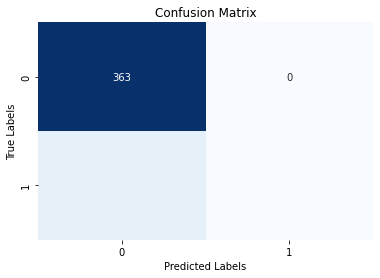

Prediction distribution: {0: 395}

Average Metrics Across All Folds for FNN:
Accuracy: 0.9190
Precision: 1.0000
Recall: 0.0000
F1_score: 0.0000
Roc_auc: 0.6152
Auprc: 0.1501


In [17]:
# Running cross-validation on MinMax Scaled data
print("\nMinMax Scaled Data - Logistic Regression Cross-Validation:")
logistic_regression_cv(X_train_minmax, y_train_minmax)
print("\nMinMax Scaled Data - FNN Cross-Validation:")
fnn_cv(X_train_minmax.values, y_train_minmax.values, input_dim=X_train_minmax.shape[1])
